# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F

import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from sklearn.model_selection import train_test_split

# Set Random Seed

In [2]:
random_seed = 42
random.seed(random_seed)
torch.manual_seed(random_seed)

# Set Global Variables

In [3]:
# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 28

# Number of training epochs
epochs = 10

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

DEVICE = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

# Create Preprocessing Functions

In [4]:
def get_fashion_mnist_0_and_1(root='./data', train=True, transform=None, download=True):
    # Load the Fashion MNIST dataset
    dataset = dset.FashionMNIST(root=root, train=train, transform=transform, download=download)
    
    # Filter the dataset to only include samples with labels 0 and 1
    targets = dataset.targets
    idx = (targets == 0) | (targets == 1)
    filtered_indices = torch.where(idx)[0]
    filtered_dataset = Subset(dataset, filtered_indices)
    
    return filtered_dataset

def get_dataloader(batch_size=64, root='./data'):
    # Define the transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    # Get the filtered dataset
    train_dataset = get_fashion_mnist_0_and_1(root=root, train=True, transform=transform, download=True)
    test_dataset = get_fashion_mnist_0_and_1(root=root, train=False, transform=transform, download=True)
    
    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Load Data

In [5]:
train_loader, test_loader = get_dataloader(batch_size=batch_size)

# EDA

## Visualize the images

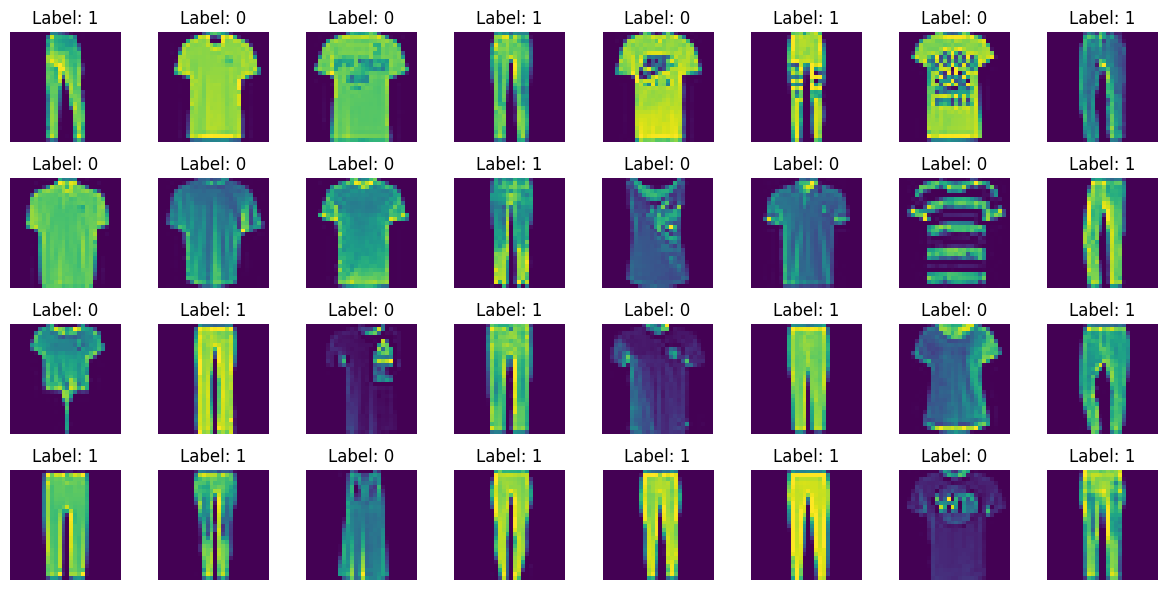

In [6]:
# Function to visualize data
def imshow(img, ax):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Visualize the data with labels
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()
for i in range(32):  # Display first 32 images
    img, label = images[i], labels[i].item()
    ax = axes[i]
    imshow(img, ax)
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# GAN Model

## Generator

### Generator Architecture

In [7]:
class Generator(nn.Module):
    def __init__(self, ngpu, noise_dim, label_dim, image_size):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.label_emb = nn.Embedding(label_dim, label_dim)
        self.init_size = image_size // 4
        self.l1 = nn.Sequential(nn.Linear(noise_dim + label_dim, 128))
        self.l2 = nn.Sequential(nn.Linear(128, 256))
        self.l3 = nn.Sequential(nn.Linear(256, 512))
        self.l4 = nn.Sequential(
            nn.Linear(512, image_size * image_size),
            nn.Tanh()
        )  

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        input_combined = torch.cat((noise, label_input), -1)
        out = F.relu(self.l1(input_combined))
        out = F.relu(self.l2(out))
        out = F.relu(self.l3(out))
        out = torch.tanh(self.l4(out))
        out = out.view(out.size(0), 1, image_size, image_size)  # Assuming MNIST images (28x28)
        return out.view(out.size(0), 1, image_size, image_size)

### Initialize Generator

In [8]:
noise_dim = 100
label_dim = 2

In [9]:
# Create the generator
generator = Generator(ngpu, noise_dim, label_dim, image_size).to(DEVICE)

# Handle multi-GPU if desired
if (DEVICE.type == 'cuda') and (ngpu > 1):
    generator = nn.DataParallel(generator, list(range(ngpu)))

# Print the model
print(generator)

Generator(
  (label_emb): Embedding(2, 2)
  (l1): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
  )
  (l2): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
  )
  (l3): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
  )
  (l4): Sequential(
    (0): Linear(in_features=512, out_features=784, bias=True)
    (1): Tanh()
  )
)


## Discriminator

### Discriminator Architecture

In [10]:
class Discriminator(nn.Module) :
    def __init__(self, ngpu, label_dim, image_size) :
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.label_emb = nn.Embedding(label_dim, label_dim)
        self.l1 = nn.Sequential(nn.Linear(image_size * image_size + label_dim, 512))
        self.l2 = nn.Sequential(nn.Linear(512, 1024))
        self.l3 = nn.Sequential(nn.Linear(1024, 1024))
        self.l4 = nn.Sequential(nn.Linear(1024, 512))
        self.out = nn.Sequential(nn.Linear(512, 1))
        
    def forward(self, image, labels) :
        label_input = self.label_emb(labels)
        img_flat = image.view(image.size(0), -1)
        input_combined = torch.cat((img_flat, label_input), -1)
        out = F.relu(self.l1(input_combined), 0.2)
        out = F.relu(self.l2(out), 0.2)
        out = F.relu(self.l3(out), 0.2)
        out = F.relu(self.l4(out), 0.2)
        out = torch.sigmoid(self.out(out))
        return out

### Initialize Discriminator

In [11]:
# Create the Discriminator
discriminator = Discriminator(ngpu, label_dim, image_size).to(DEVICE)

# Handle multi-GPU if desired
if (DEVICE.type == 'cuda') and (ngpu > 1):
    discriminator = nn.DataParallel(discriminator, list(range(ngpu)))

# Print the model
print(discriminator)

Discriminator(
  (label_emb): Embedding(2, 2)
  (l1): Sequential(
    (0): Linear(in_features=786, out_features=512, bias=True)
  )
  (l2): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
  )
  (l3): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (l4): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
  )
  (out): Sequential(
    (0): Linear(in_features=512, out_features=1, bias=True)
  )
)


## Loss Function and Optimizer

In [12]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))

discriminator.to(DEVICE)
generator.to(DEVICE)
criterion.to(DEVICE)

BCELoss()

# Train Model

In [13]:
for epoch in range(epochs):
        # Initialize tqdm progress bar
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for i, (imgs, labels) in enumerate(progress_bar):
            batch_size = imgs.size(0)
            
            # Adversarial ground truths
            valid = torch.ones(batch_size, 1, requires_grad=False).to(DEVICE)
            fake = torch.zeros(batch_size, 1, requires_grad=False).to(DEVICE)
            
            # Configure input
            real_imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            # -----------------
            #  Train Generator
            # -----------------
            
            optimizerG.zero_grad()

            # Sample noise as generator input
            z = torch.randn(batch_size, noise_dim).to(DEVICE)
            gen_labels = torch.randint(0, label_dim, (batch_size,)).to(DEVICE)
            
            # Generate a batch of images
            gen_imgs = generator(z, gen_labels)

            # Loss measures generator's ability to fool the discriminator
            g_loss = criterion(discriminator(gen_imgs, gen_labels), valid)

            g_loss.backward()
            optimizerG.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------

            optimizerD.zero_grad()

            # Loss for real images
            real_loss = criterion(discriminator(real_imgs, labels), valid)
            # Loss for fake images
            fake_loss = criterion(discriminator(gen_imgs.detach(), gen_labels), fake)
            # Total discriminator loss
            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            optimizerD.step()

            # Update tqdm progress bar with losses
            progress_bar.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

Epoch 10/10: 100%|██████████| 94/94 [00:03<00:00, 27.41it/s, d_loss=0.0172, g_loss=4.38] 
